In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

import sys
import os
import time

# Get the absolute path to the directory containing 'notebooks'
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from src.simulation import simulate_comb_sbm, simulate_mf_sbm
from src.synthetic_data import generate_sbm_adjacency_matrix
from src.helper_functions import power_law_kernel, rayleigh_kernel, gaussian_kernel, sigmoid_kernel, exponential_kernel

In [10]:
# Parameters for a small two-coommunity example
final_time = 100
num_nodes1 = 500
alphas =  np.array([0.7,0.3]) 
comm_size1 = (num_nodes1 * alphas).astype(int)

prob_matrix = np.array([[0.9, 0.1],
                        [0.1, 0.9]])

exp_params1 = [0.9, 0.5]
exp_params2 = [0.5, 0.1]

kernel_params_matrix = np.array([exp_params1, exp_params2])
kernel_function_matrix = np.array([exponential_kernel, exponential_kernel])

mu_true = np.array([0.9, 0.5])
lag = 1

seed = 123
np.random.seed(seed)


In [5]:
#Generate adjecency matrix and node community labels
labs, adj_matrix = generate_sbm_adjacency_matrix(comm_size1, prob_matrix)

#Generate from exponential random variable to simulate Poisson rv
E = np.random.exponential(scale = 1.0, size = (final_time, num_nodes1, 100))

#Simulate true intenity (lmbd) and jumps (Y)
_, lmbd_comb ,X_comb = simulate_comb_sbm(E, final_time,num_nodes1,comm_size1, kernel_function_matrix, kernel_params_matrix, adj_matrix, labs, mu_vector =mu_true, lag =lag)

In [6]:
#Simulate mean field lambda and associated jumps
_, lmbd_mf, X_mf = simulate_mf_sbm(E, final_time, comm_size1, prob_matrix, kernel_function_matrix, kernel_params_matrix,mu_vector = mu_true, lag =lag)

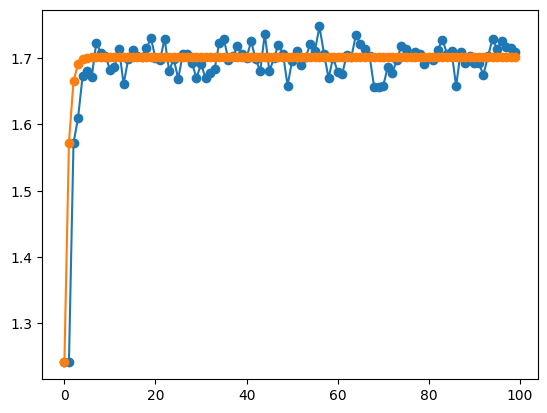

In [7]:
#See if the mean field for a chosen node is close to the true intensity (sanity check)
node_idx = 0

plt.plot(lmbd_comb[:,node_idx], label='Community 1 - COMB', marker='o')
plt.plot(lmbd_mf[:,labs[node_idx]], label='Community 1 - MF', marker = 'o')
plt.show()

In [9]:
# true paramters for the inference (do double check this as the indexing is confusing so I might have messed it up)
num_comm =len(alphas)

phi_community_one = np.array([
    [
        exponential_kernel(exp_params1, t),
        exponential_kernel(exp_params2, t),
    ]
    for t in range(1, lag+1)
])

phi_true = np.repeat(phi_community_one[:, None, :], num_comm, axis=1)
